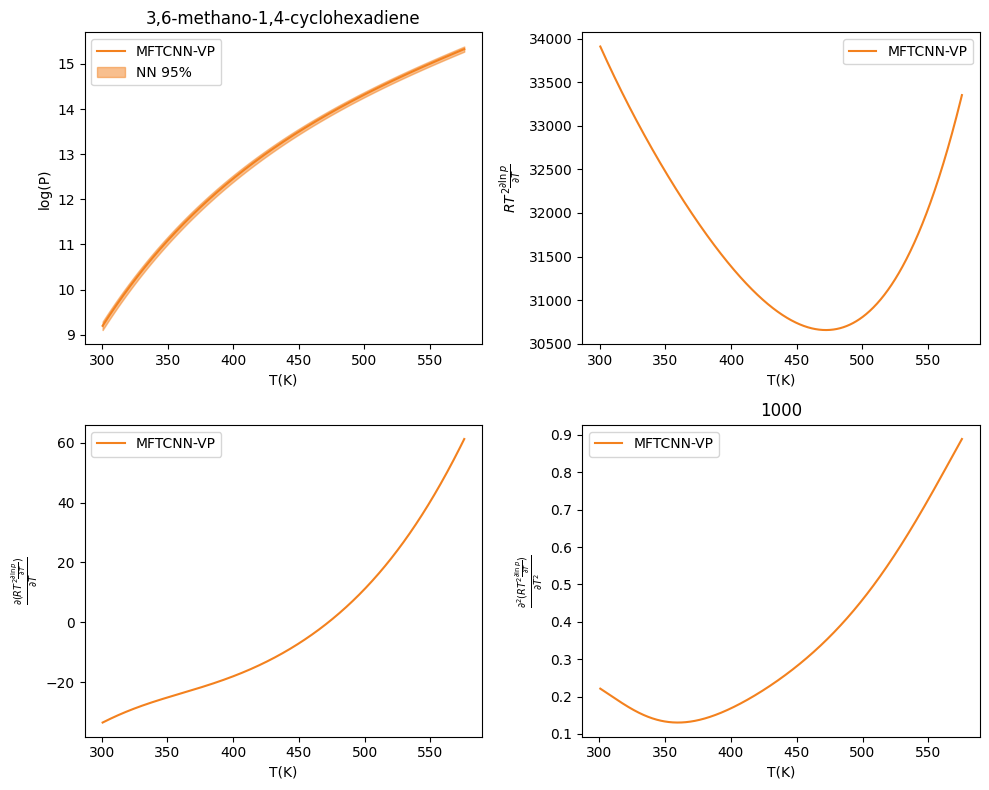

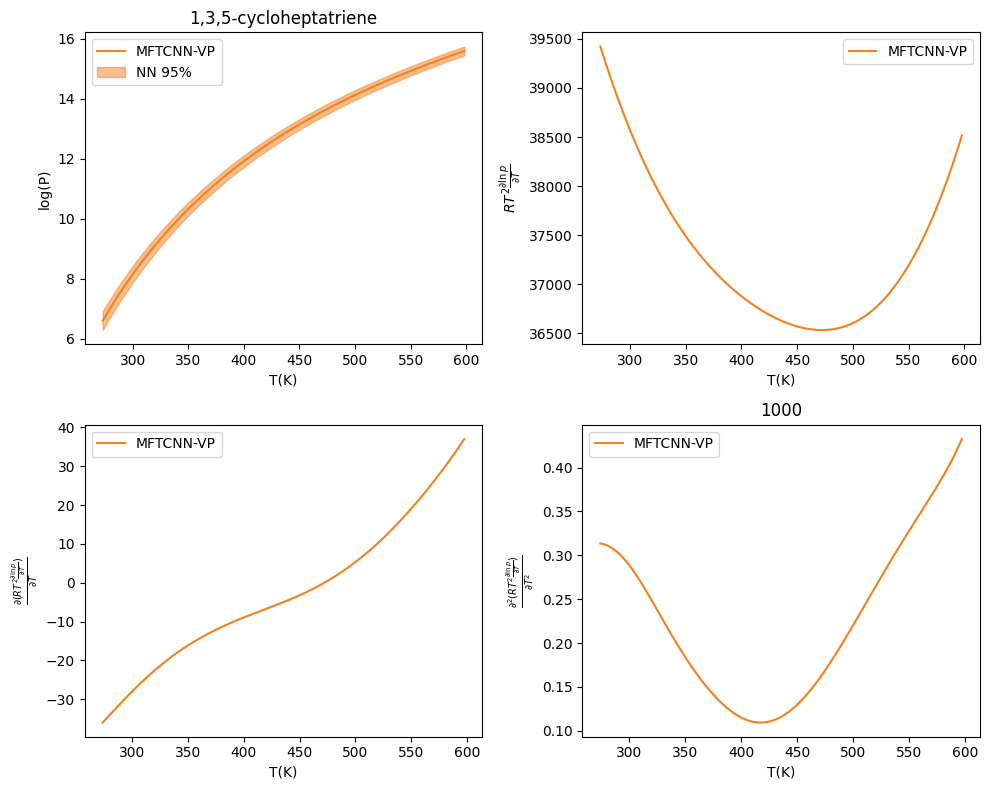

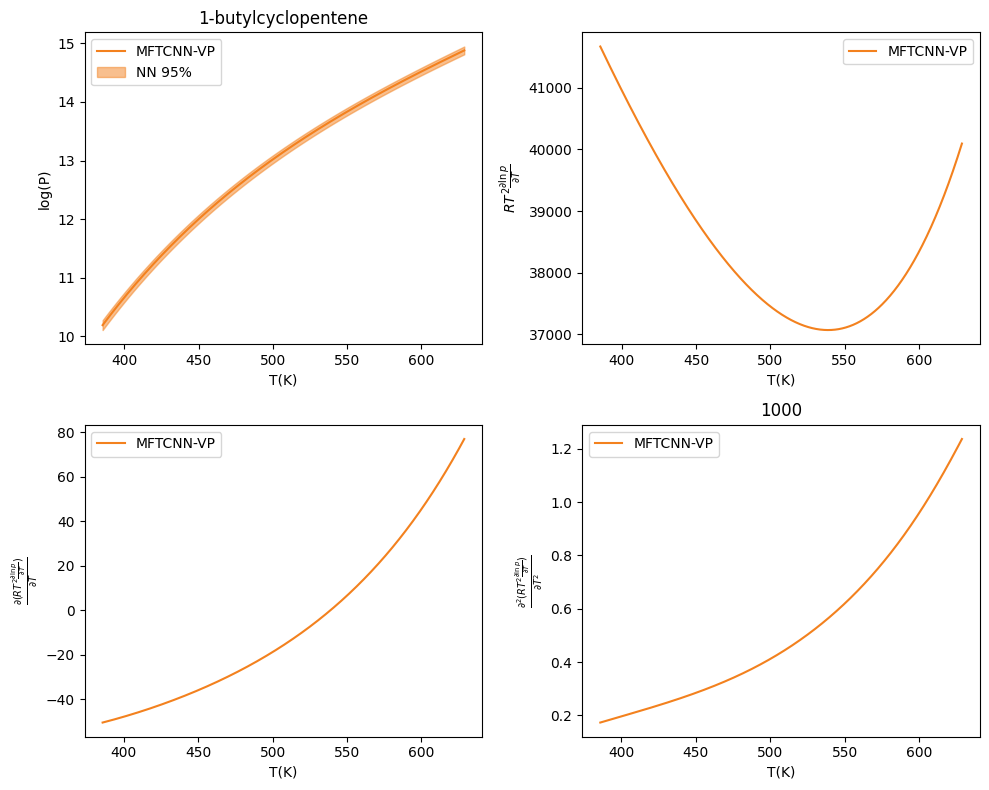

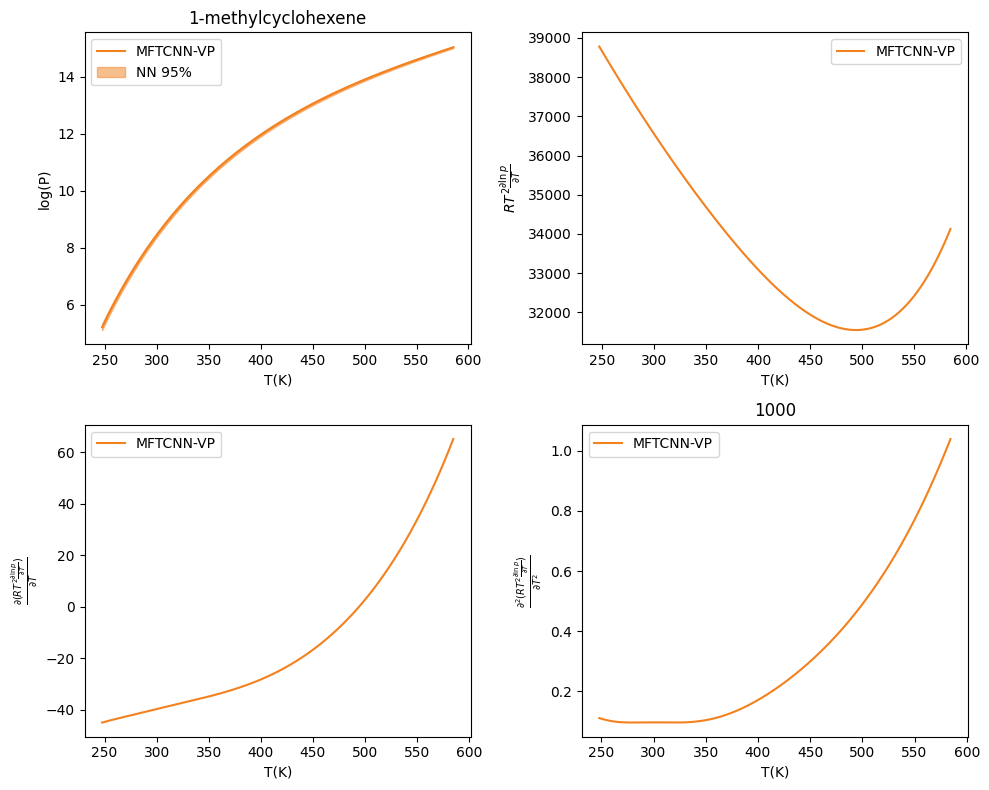

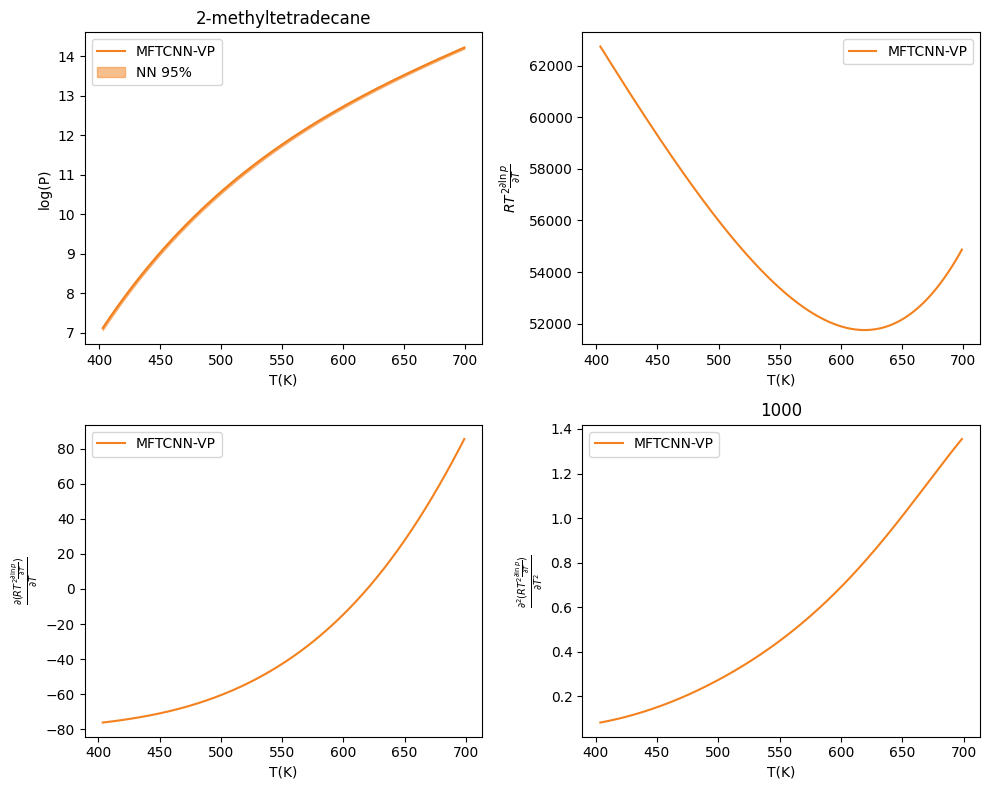

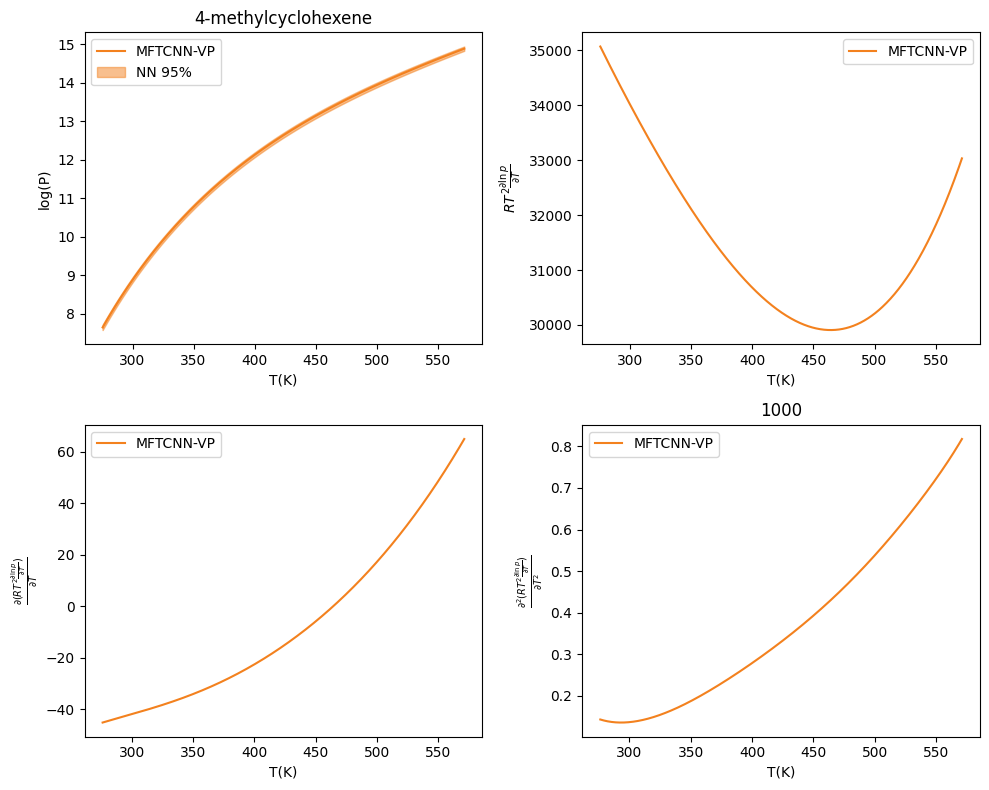

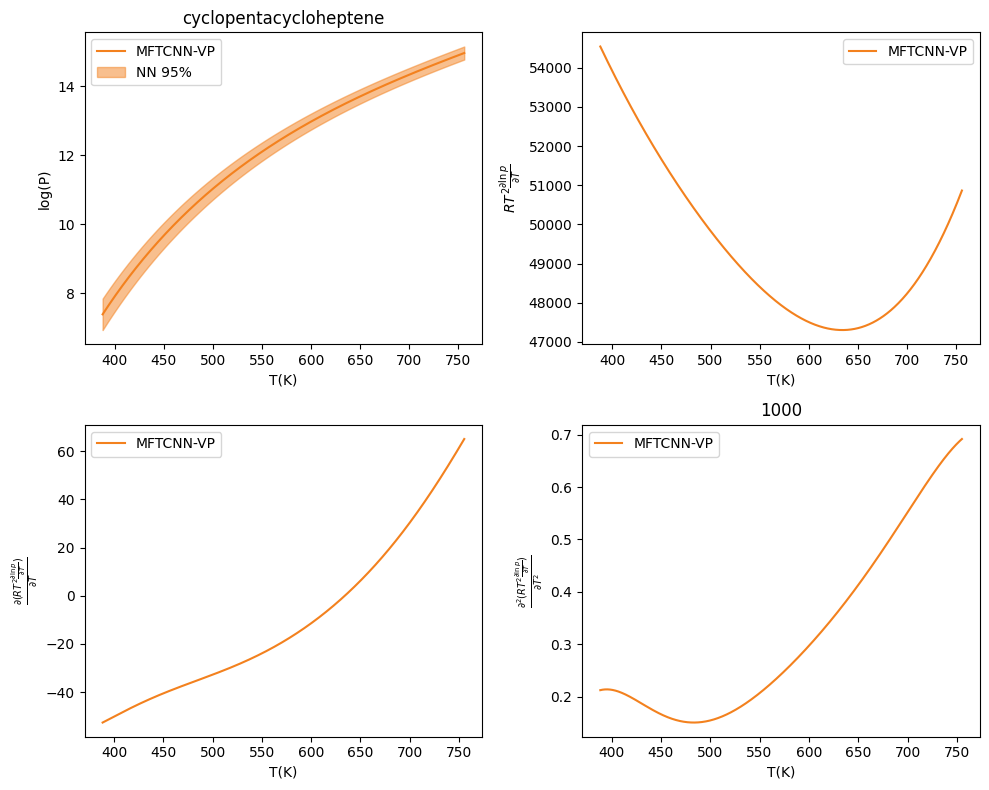

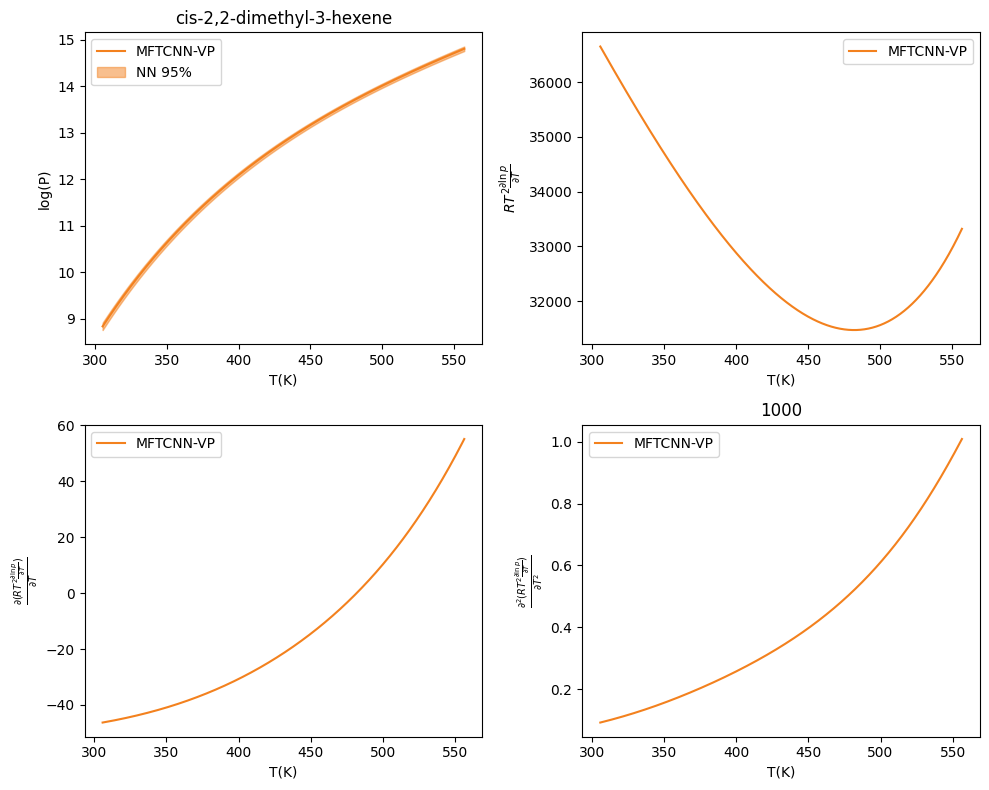

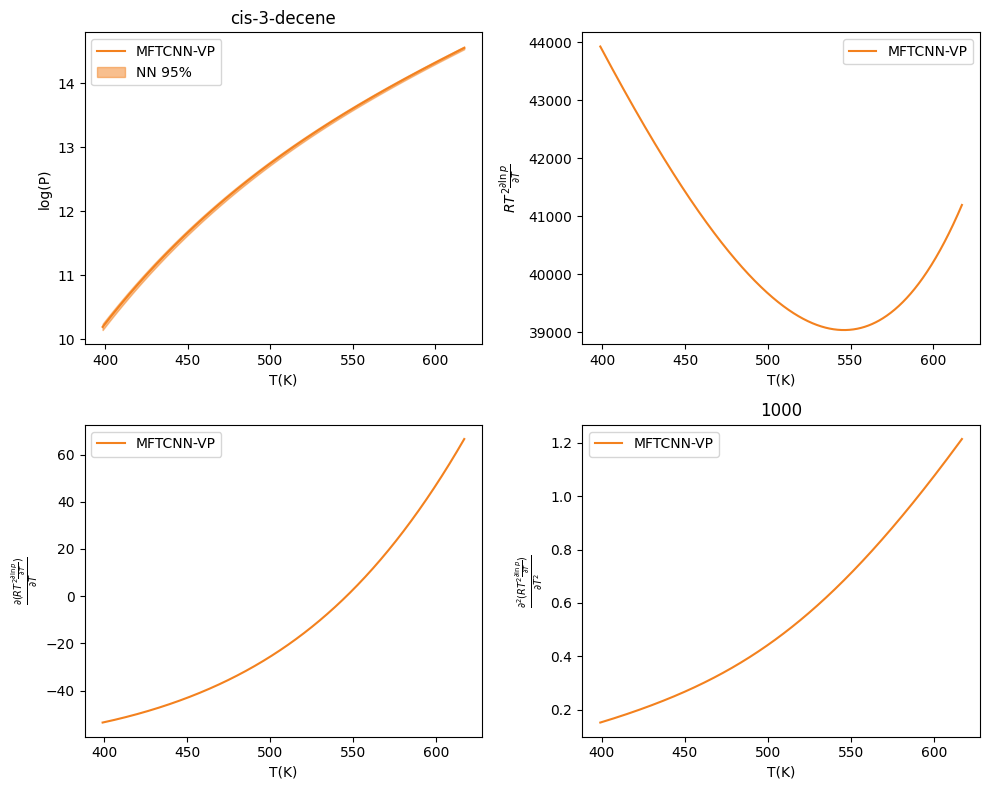

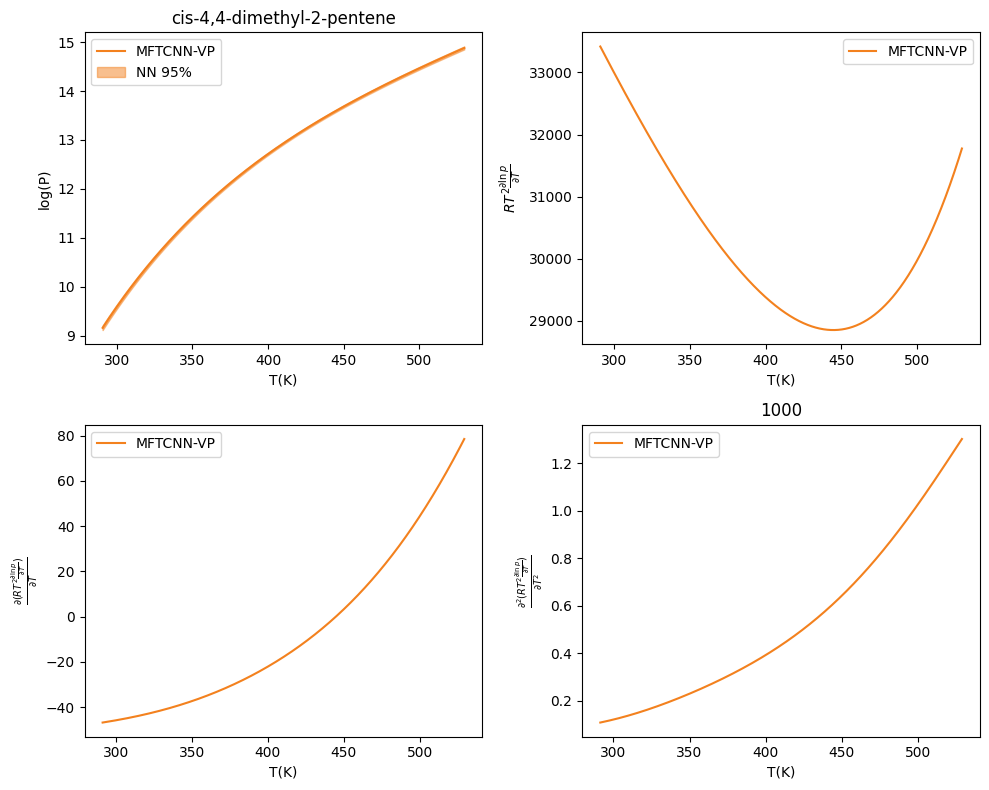

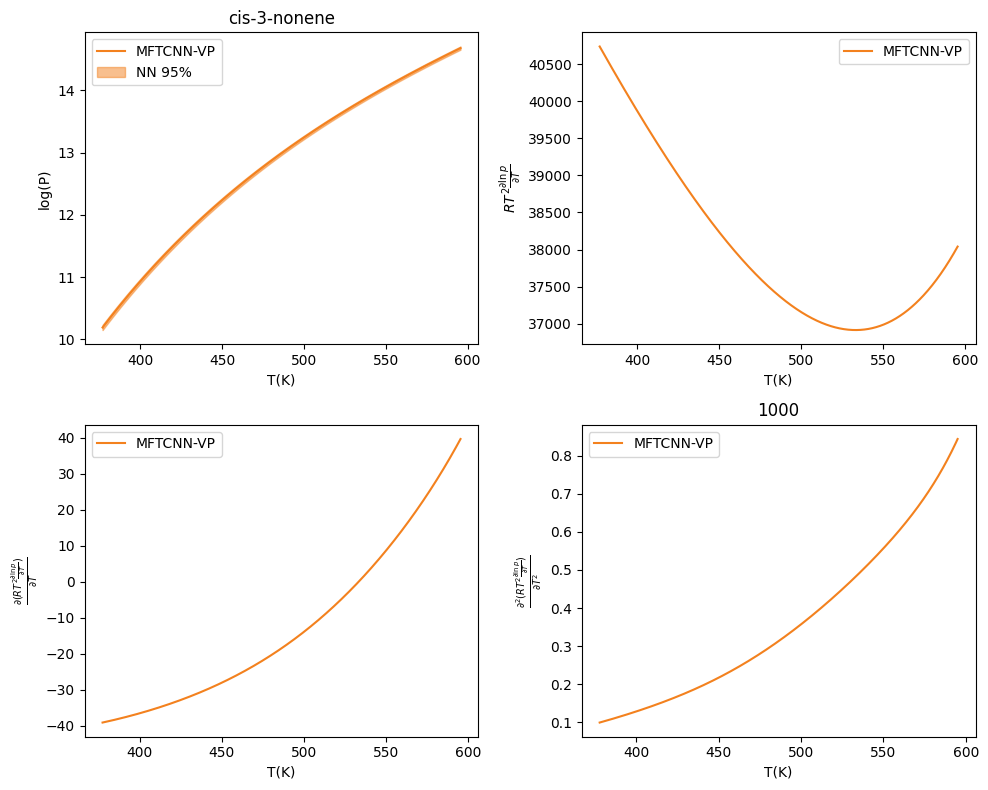

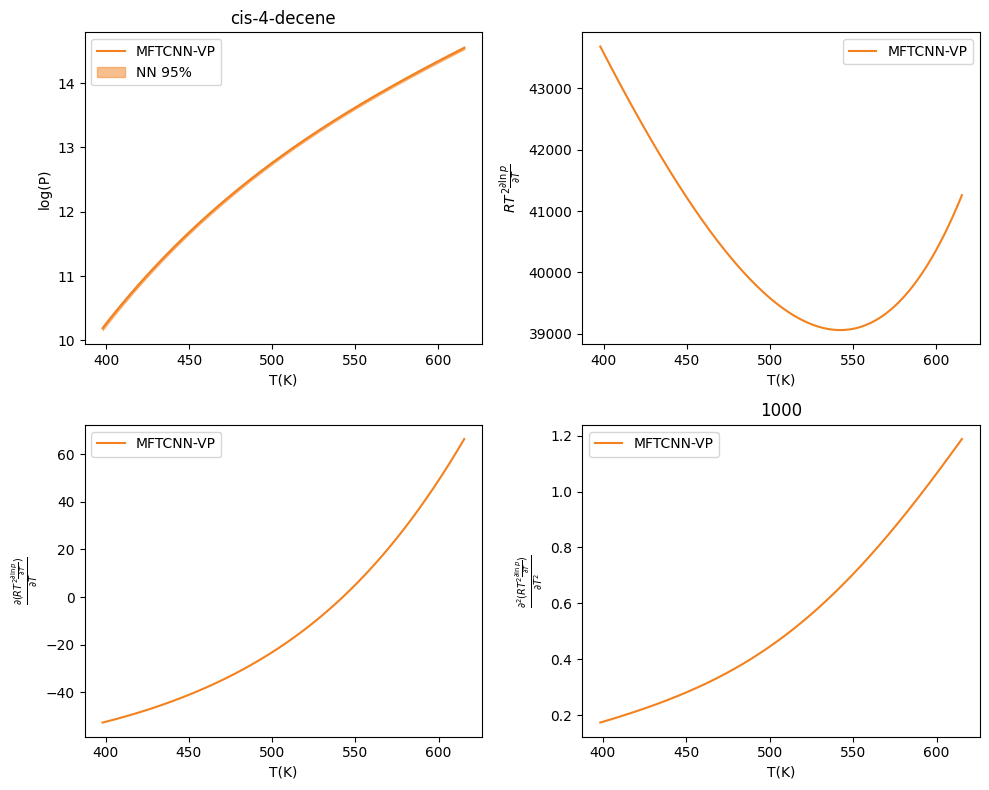

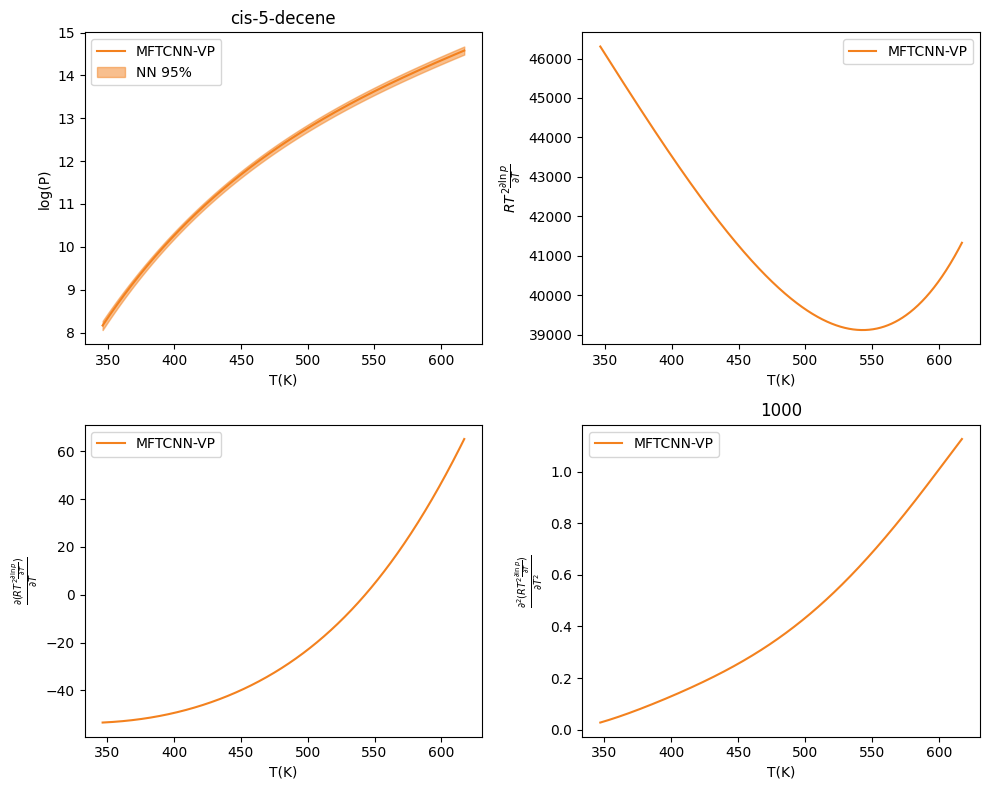

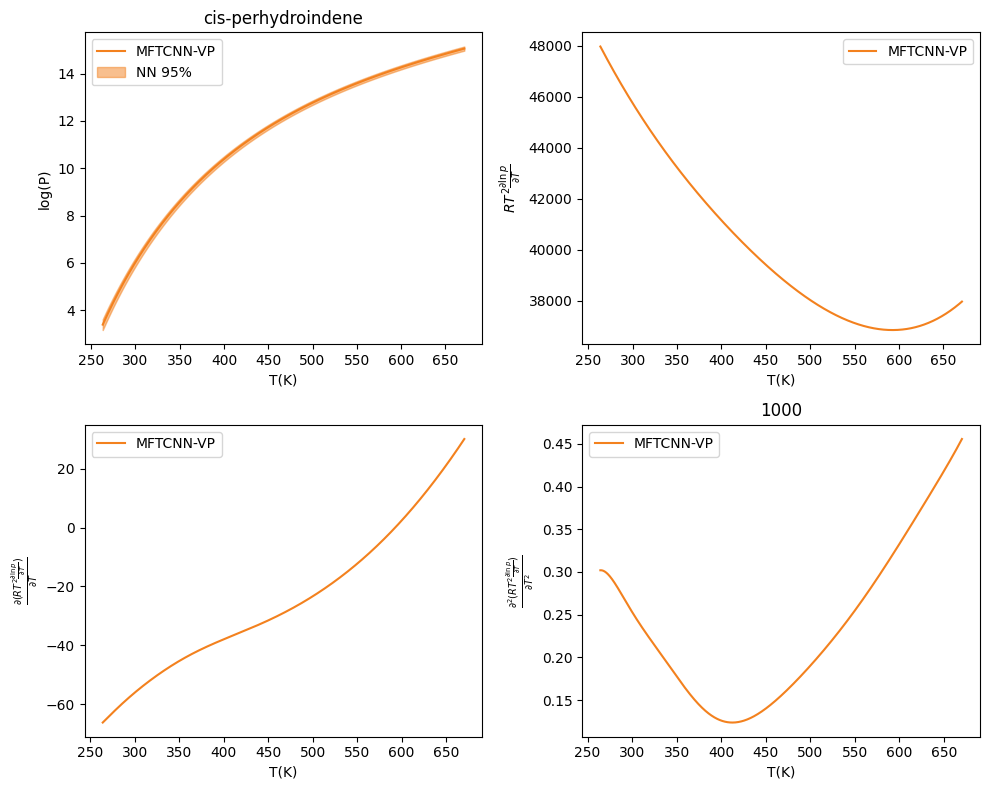

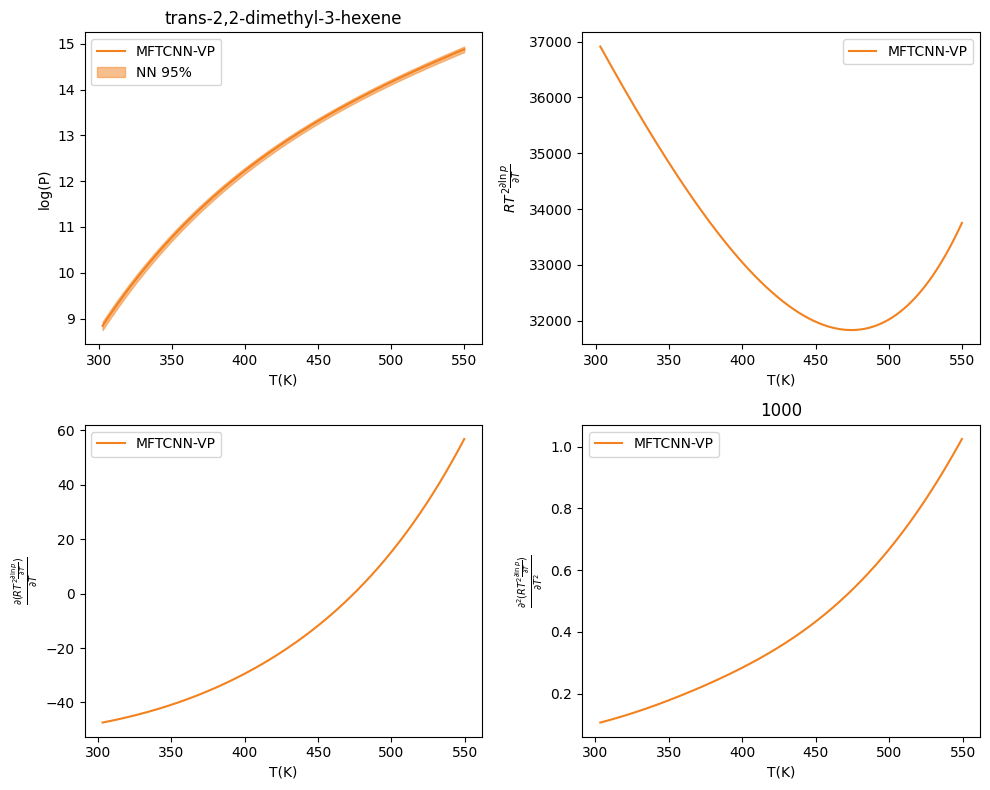

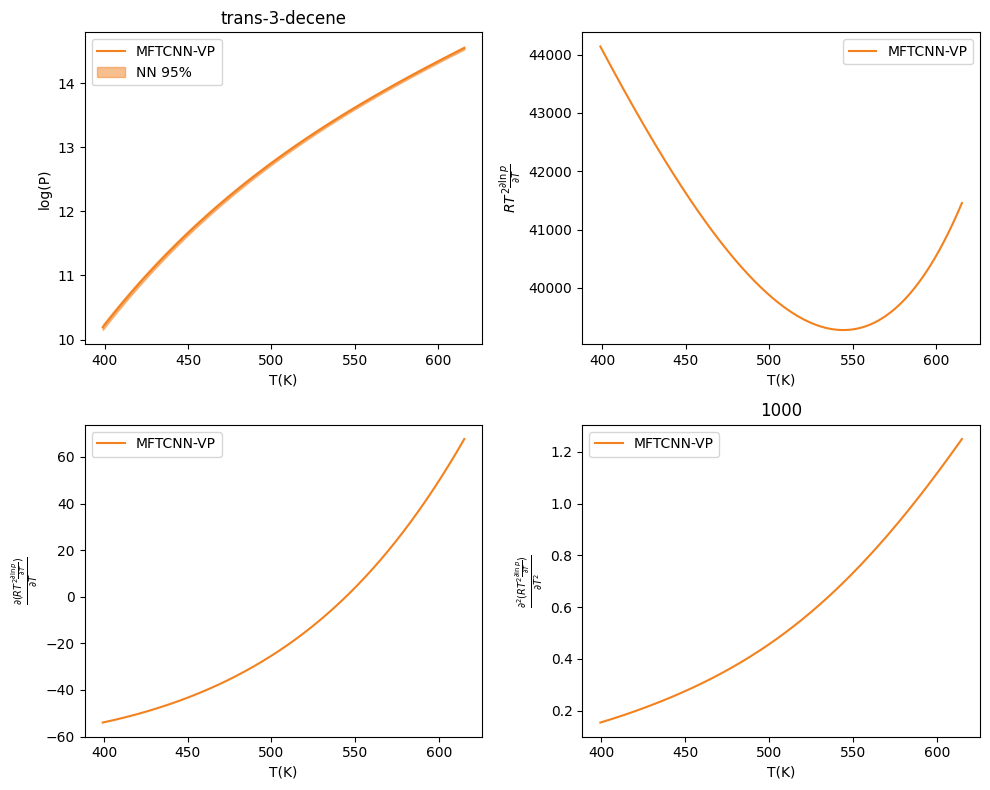

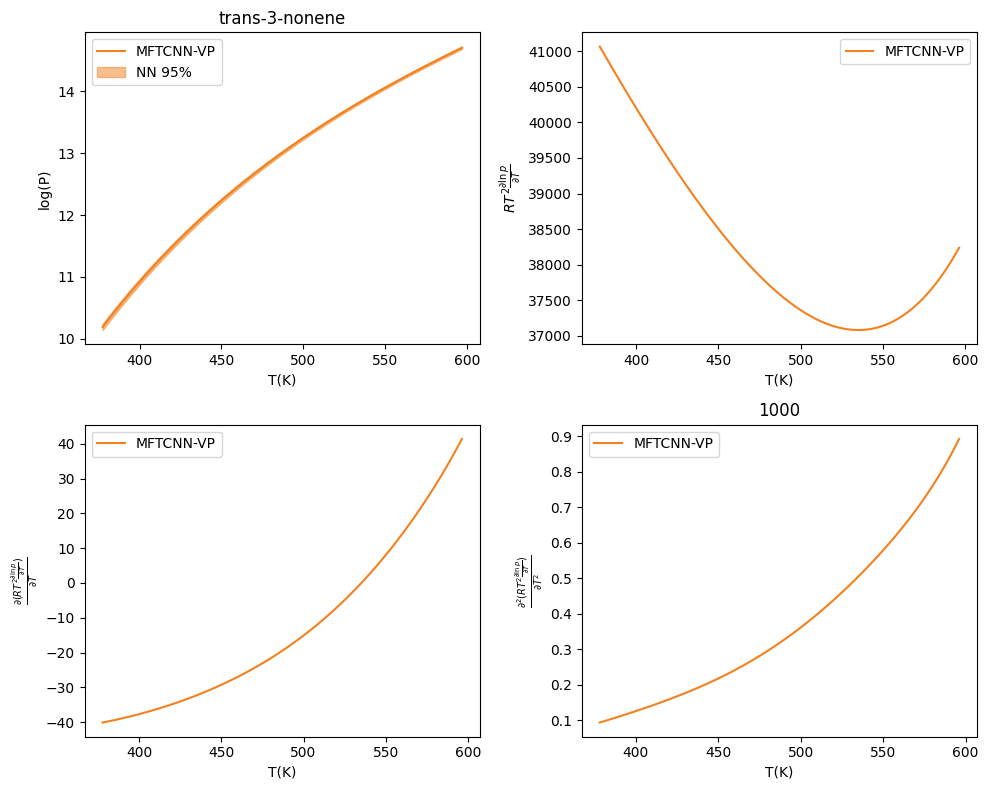

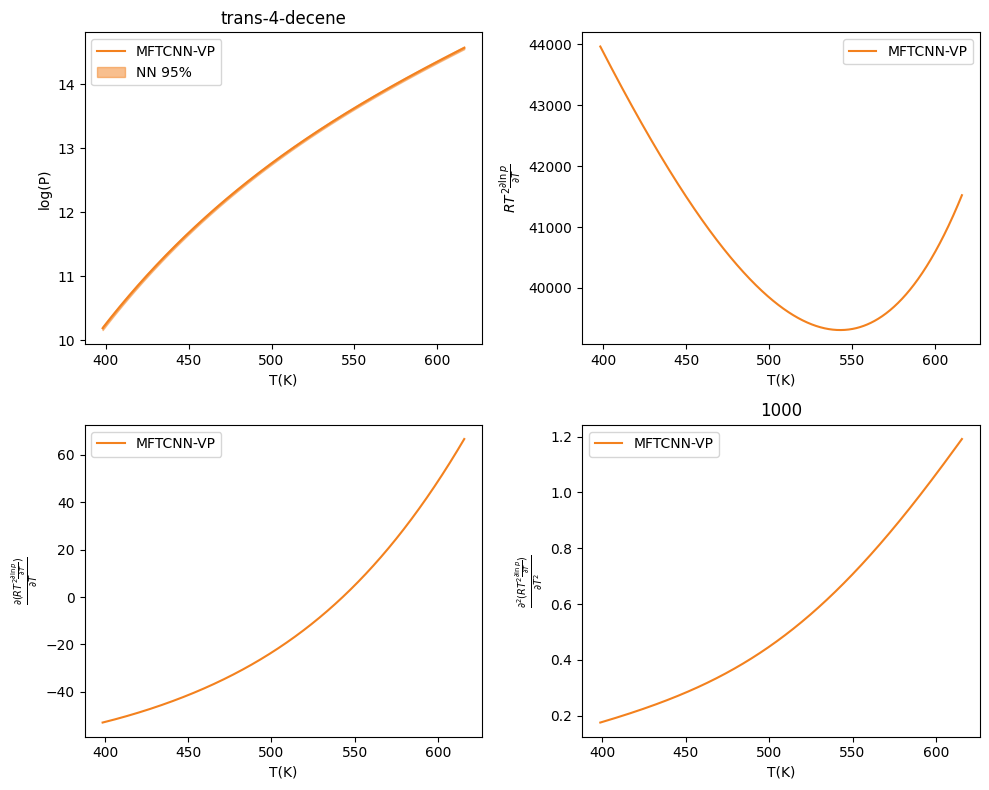

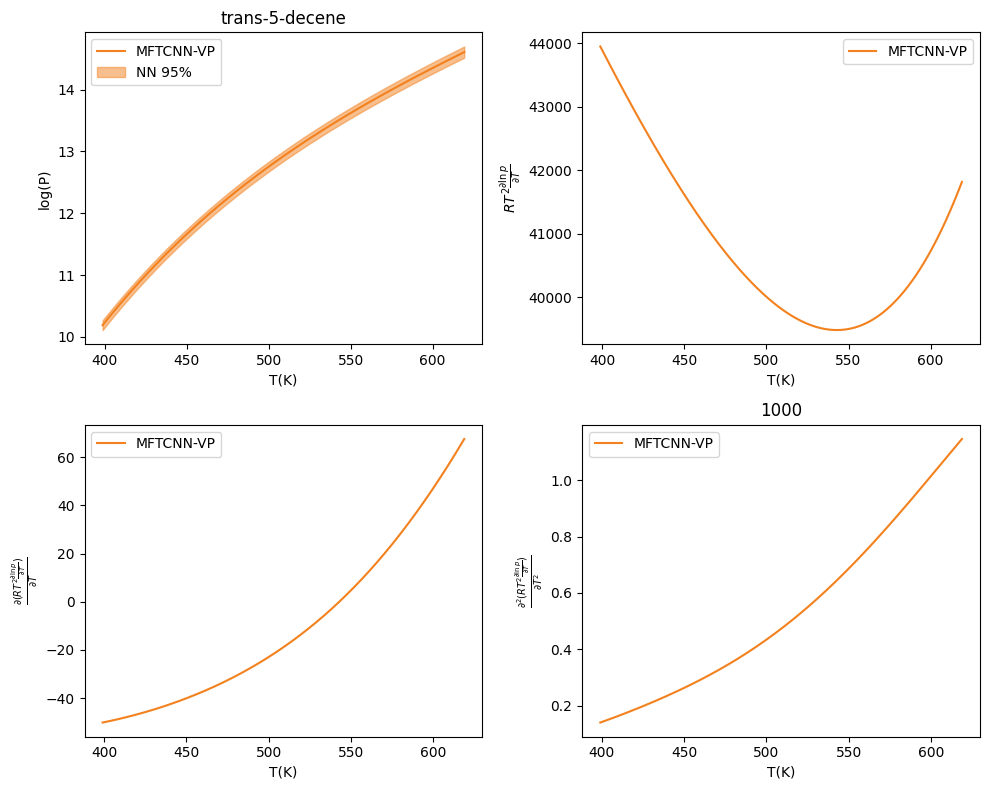

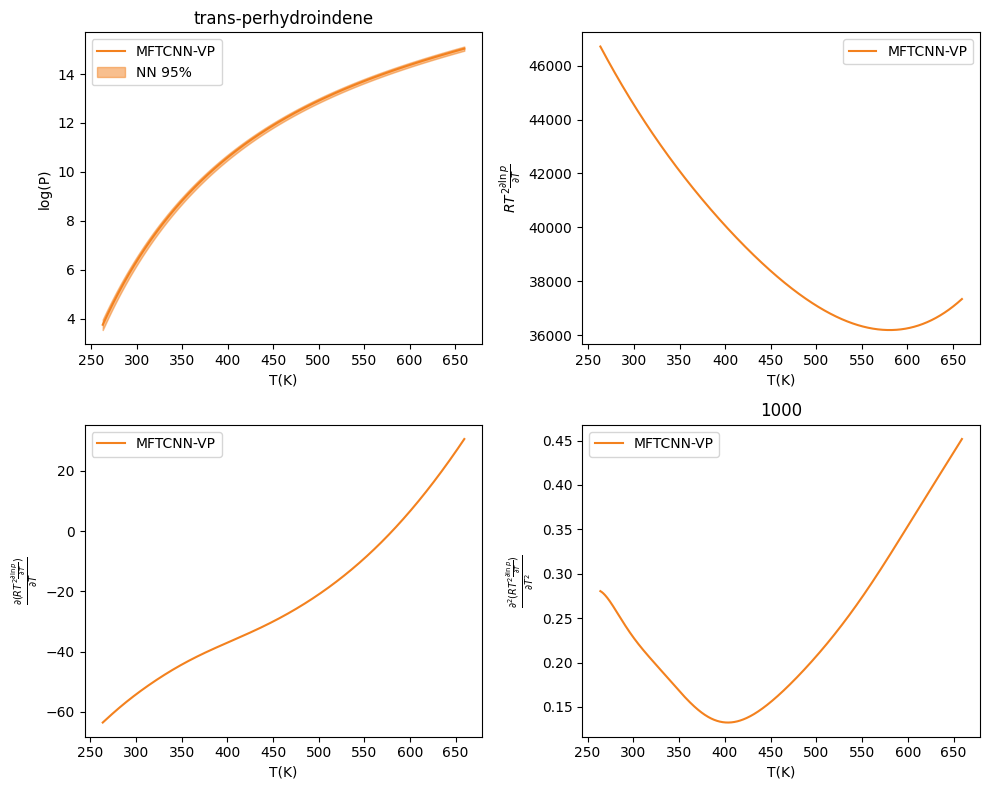

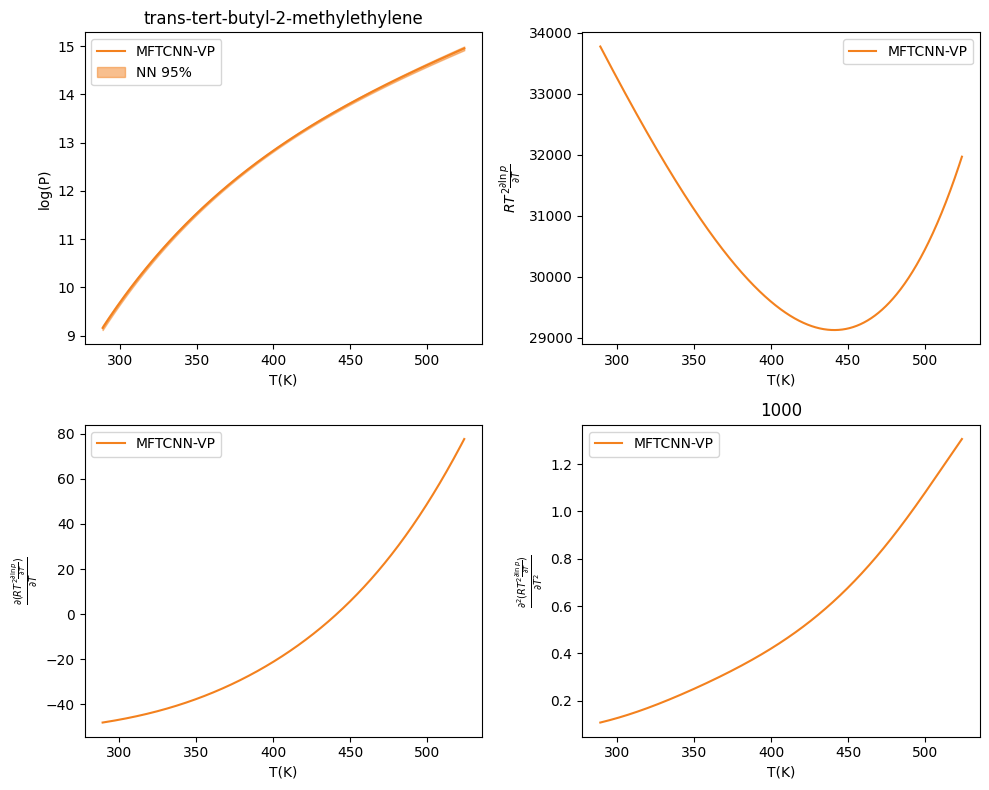

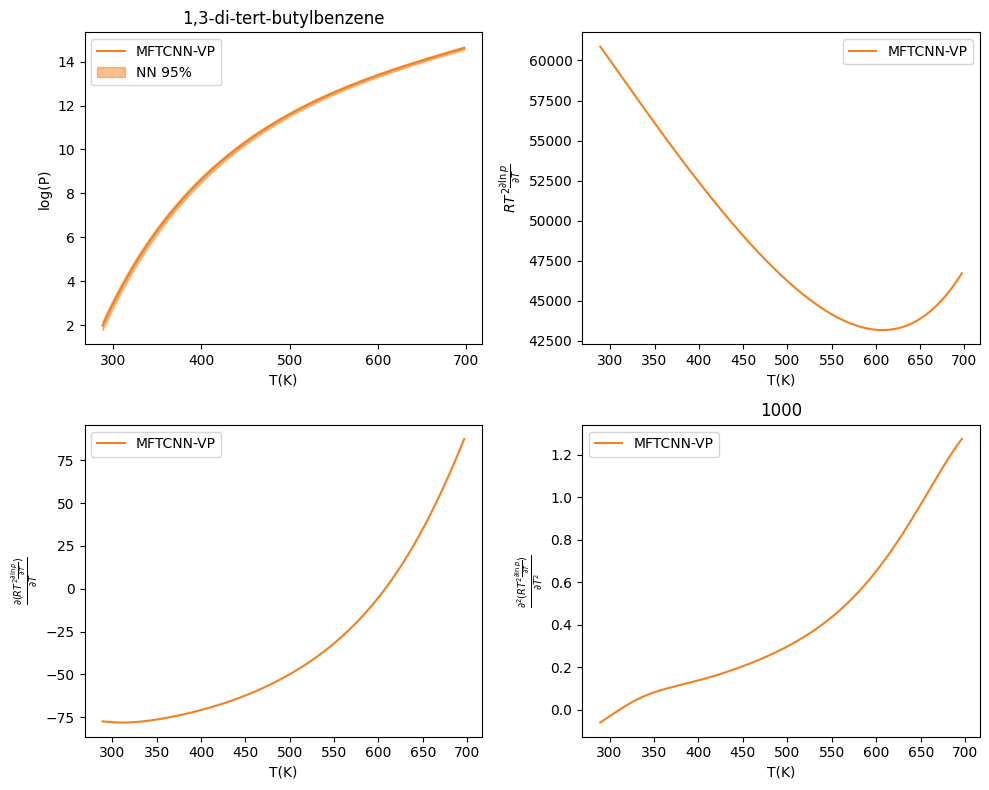

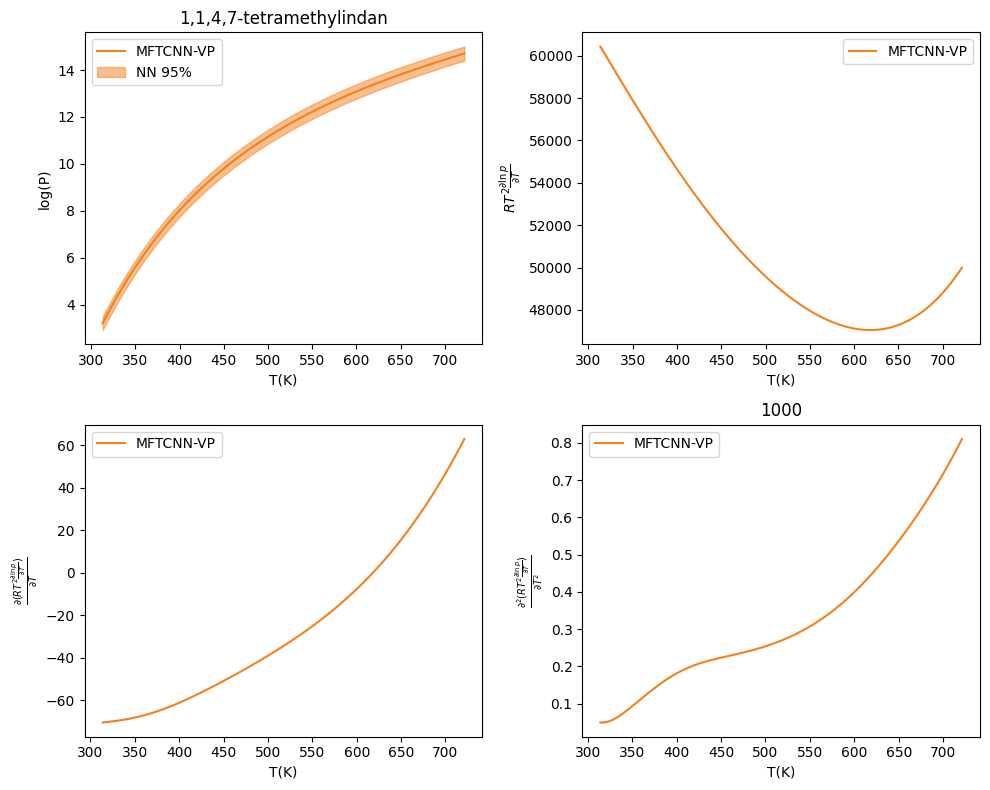

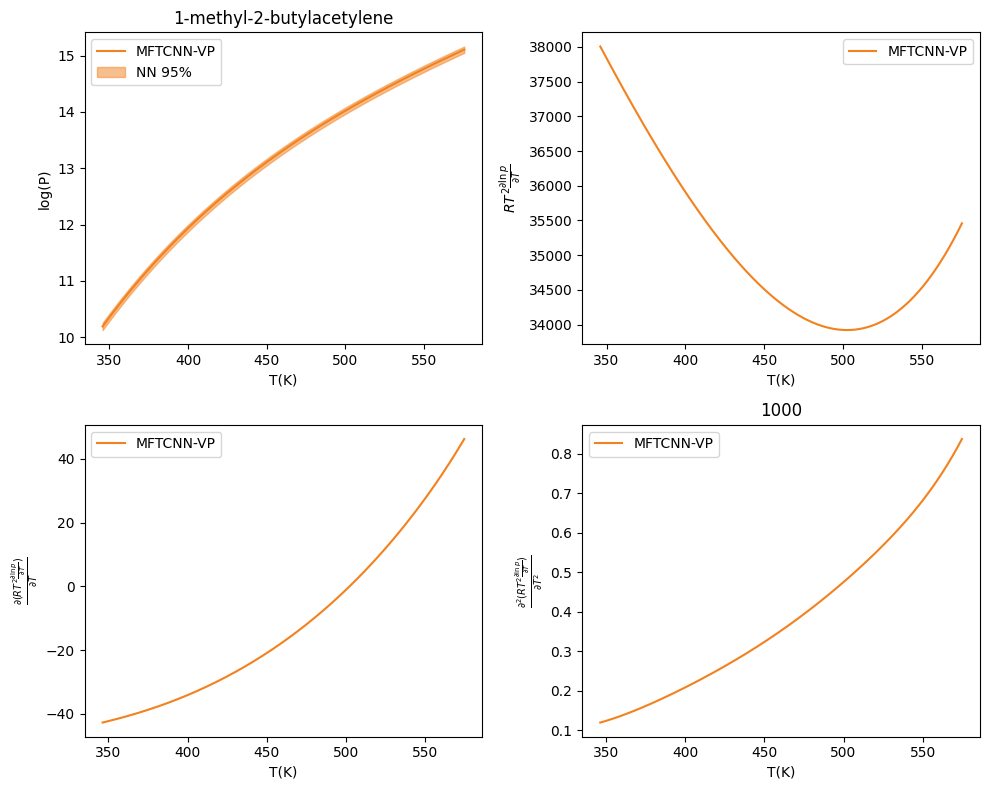

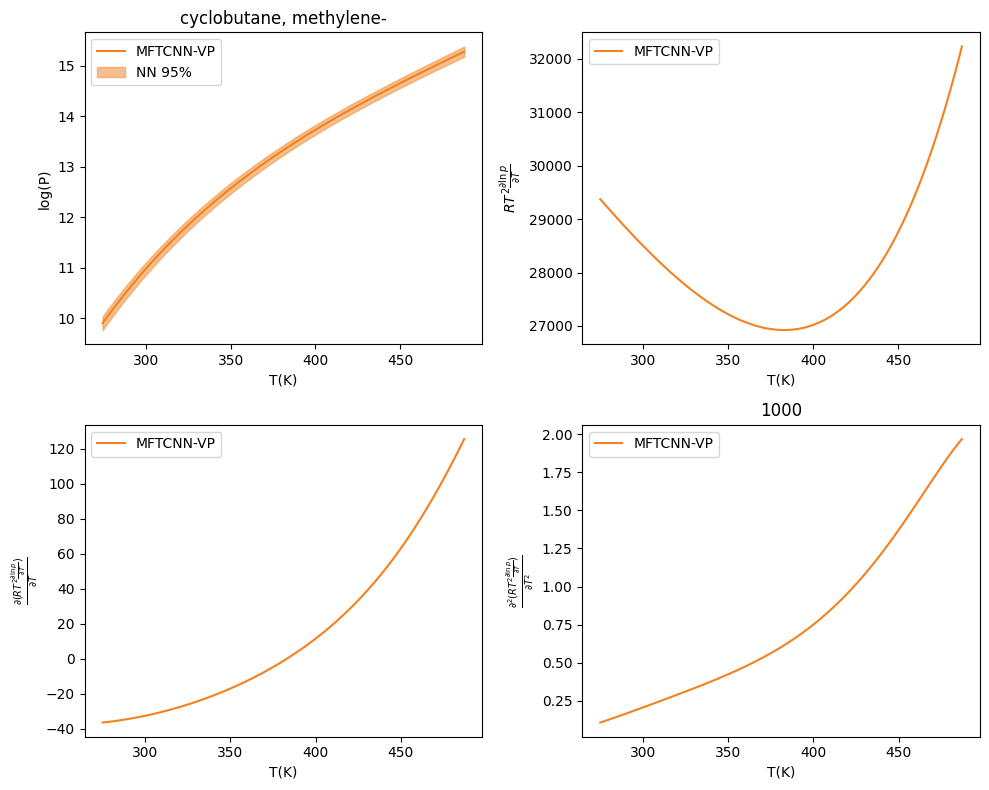

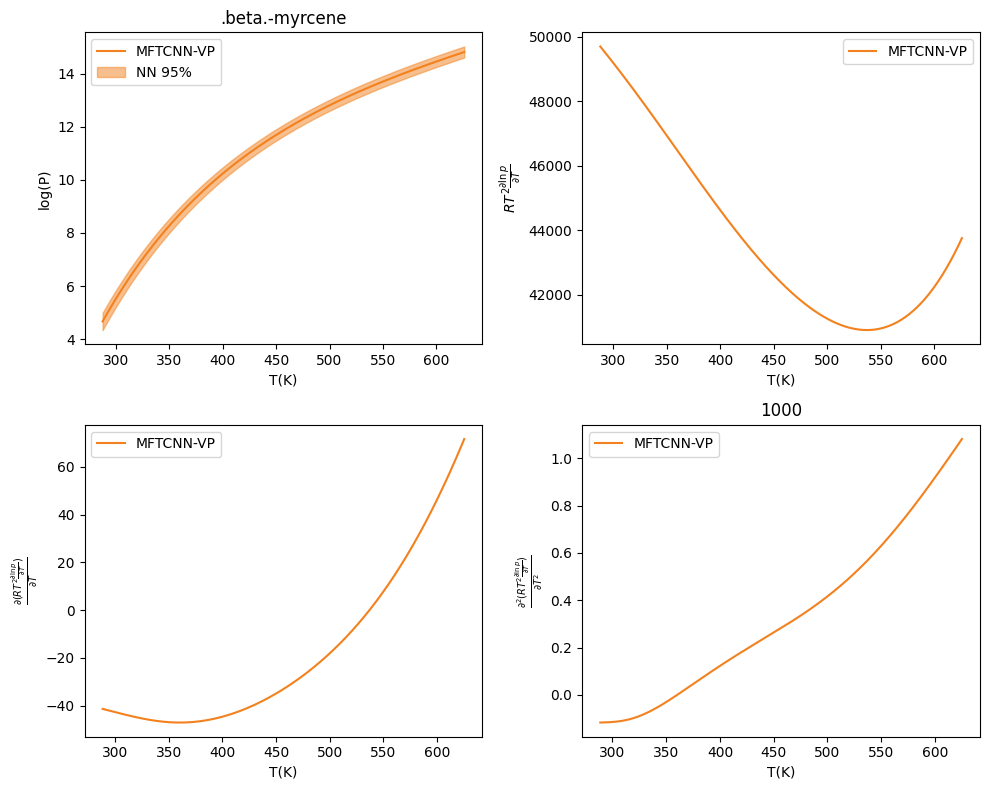

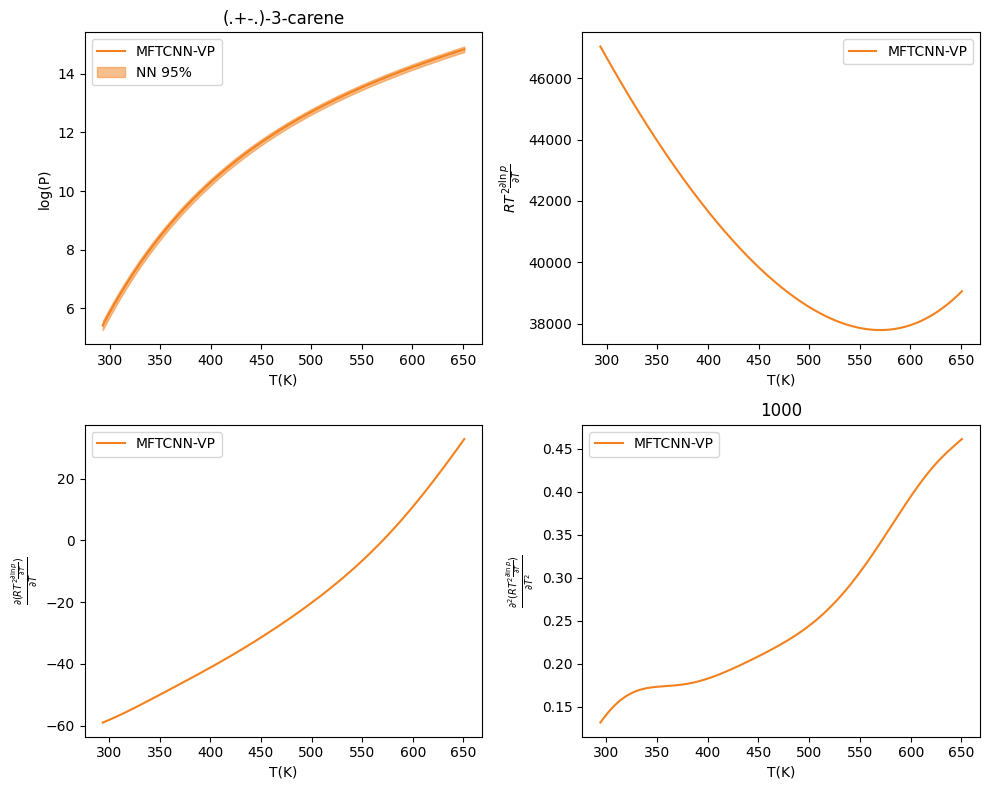

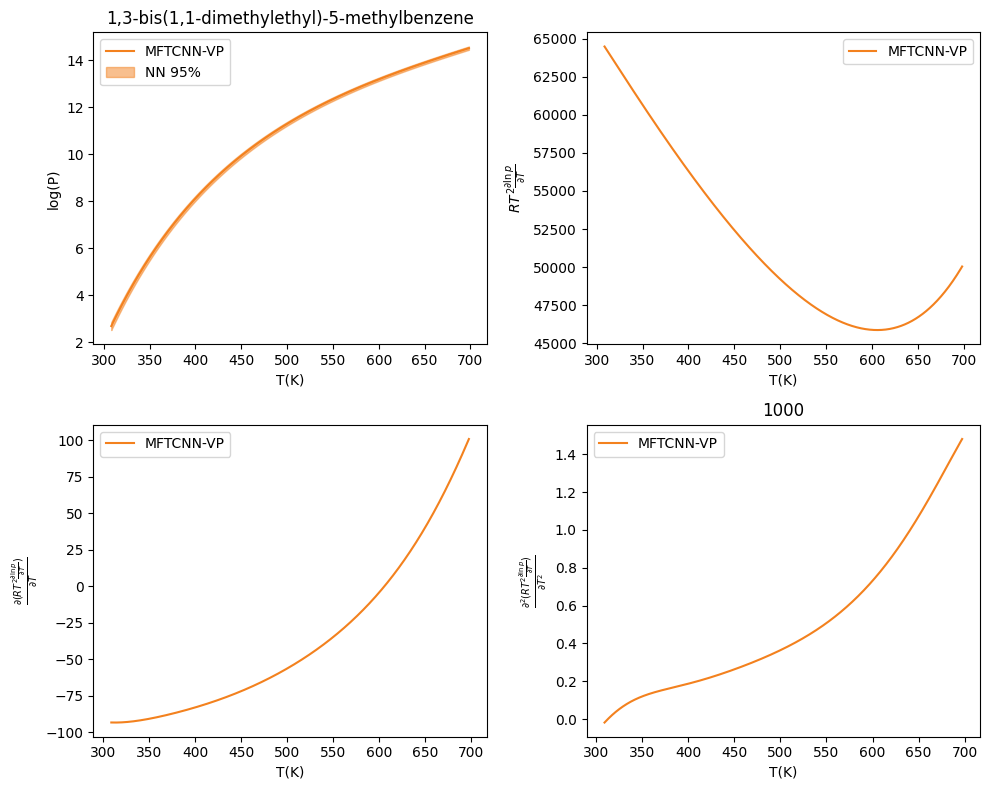

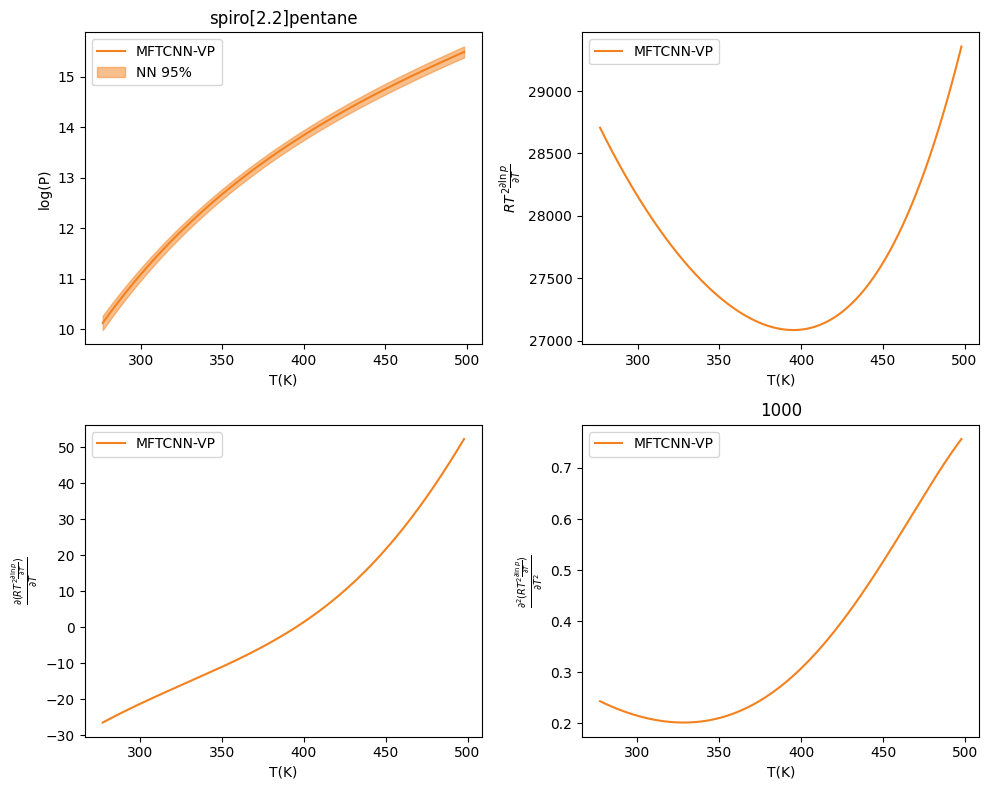

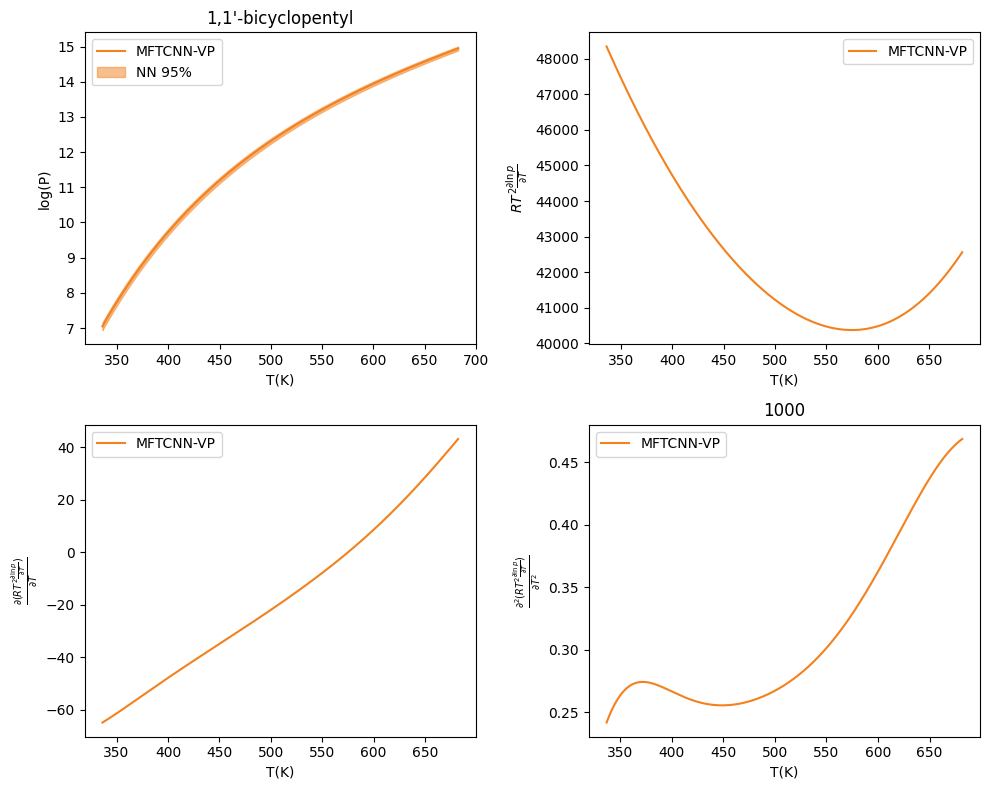

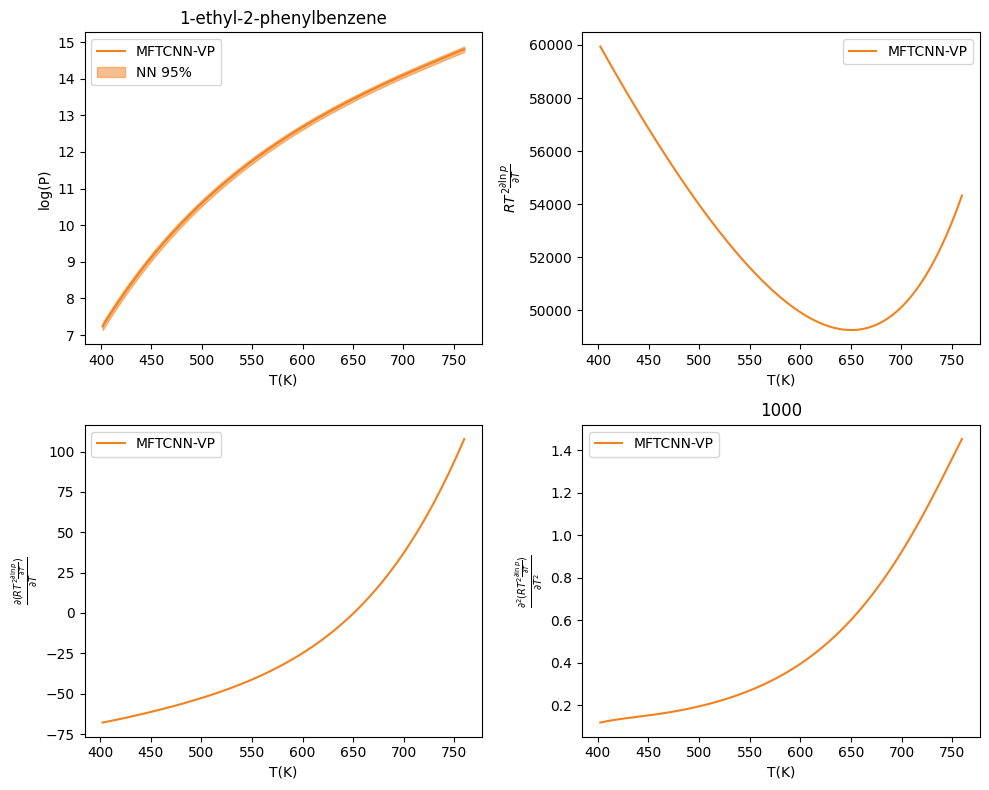

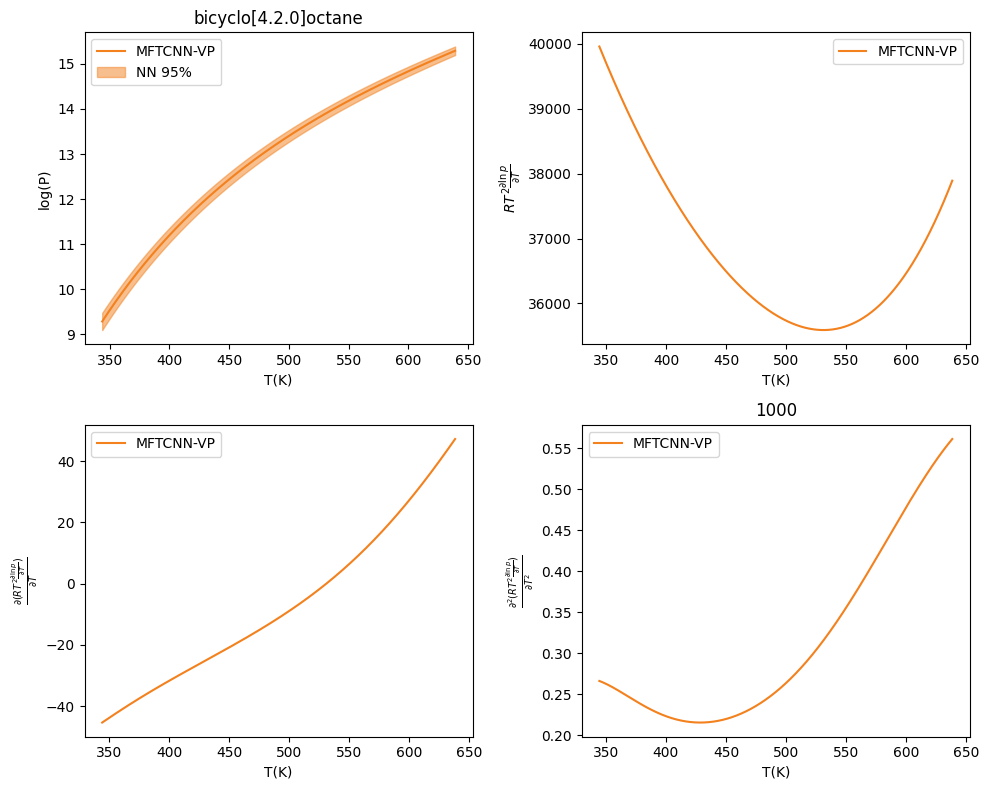

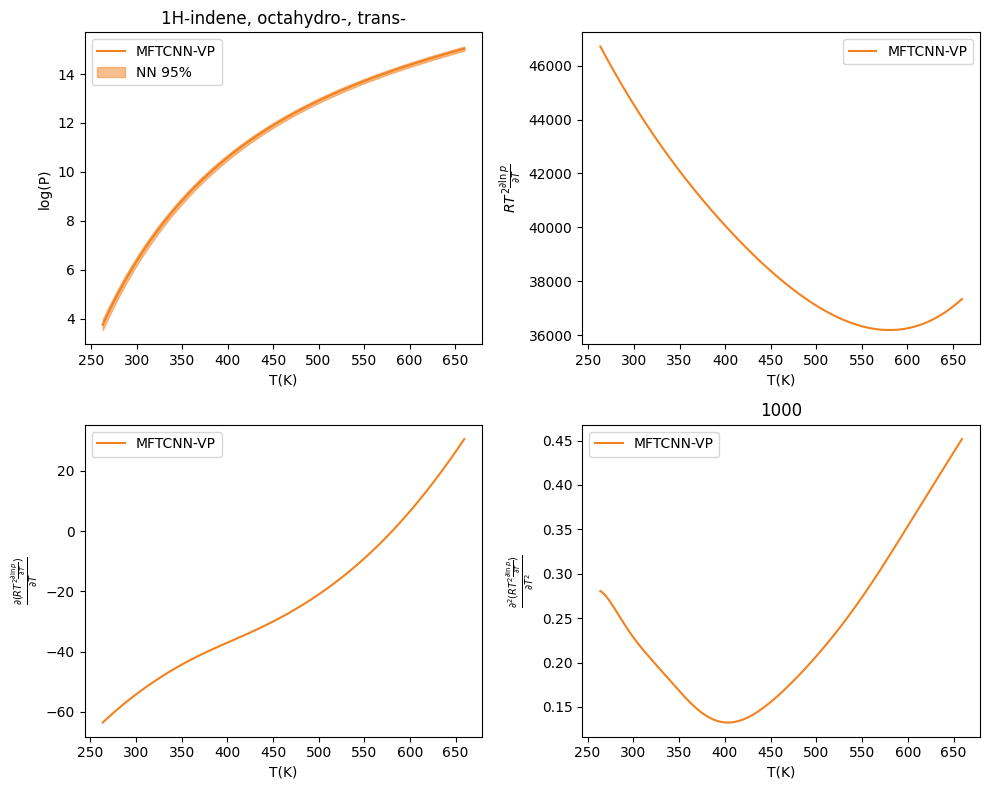

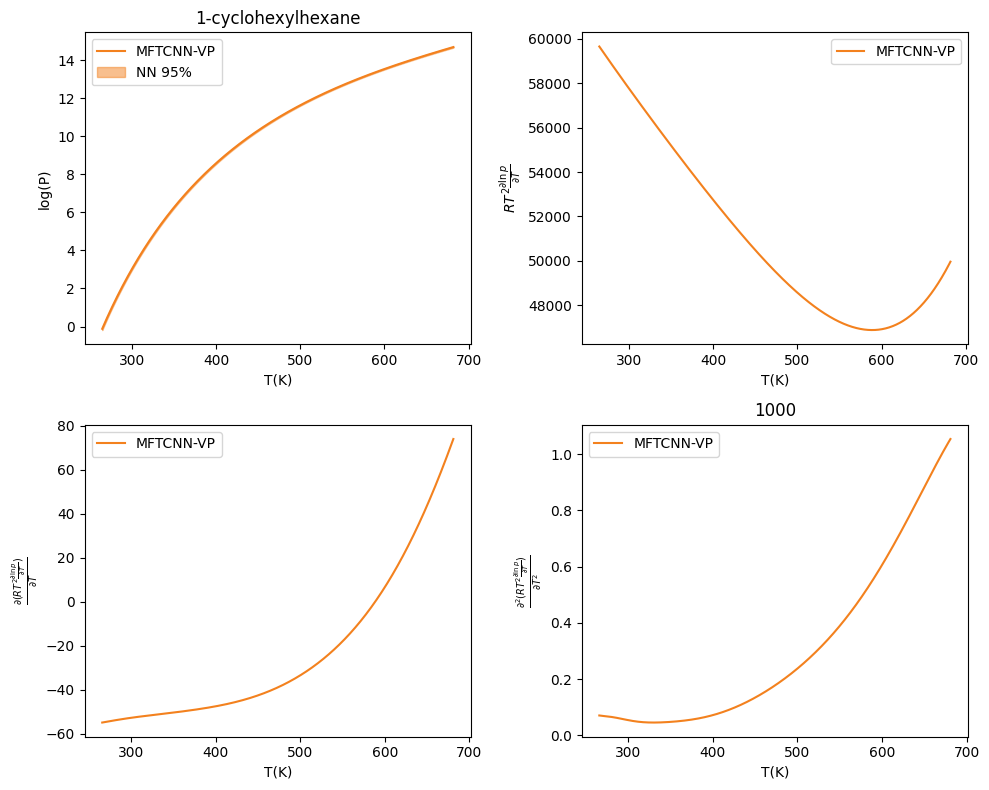

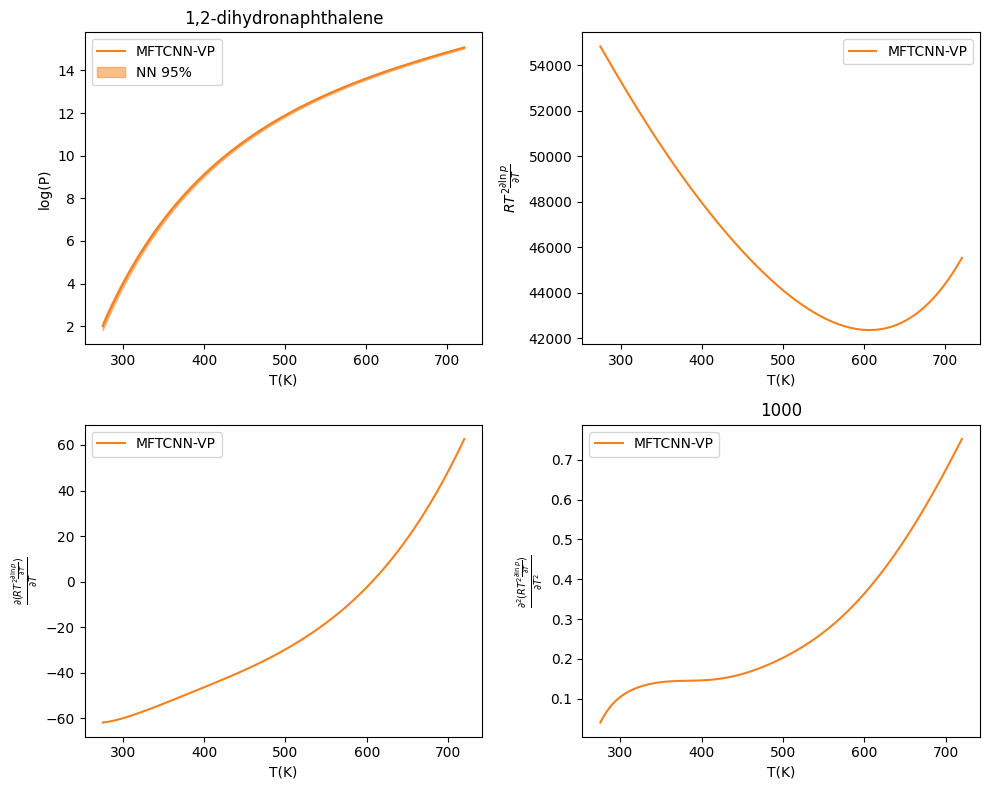

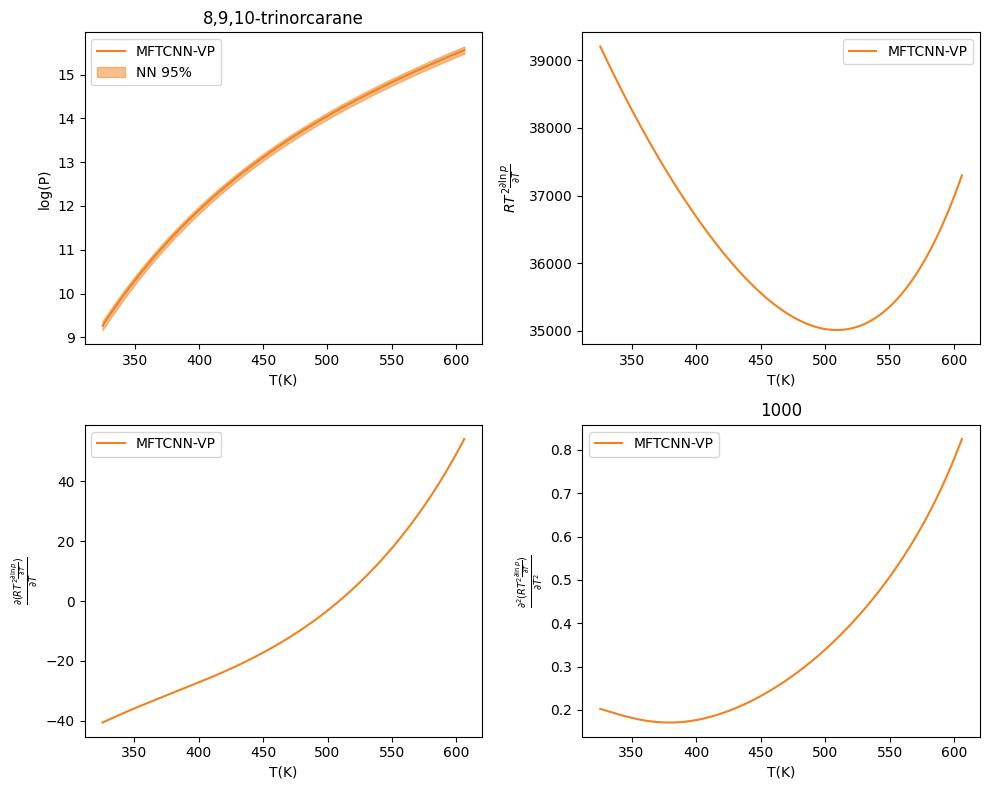

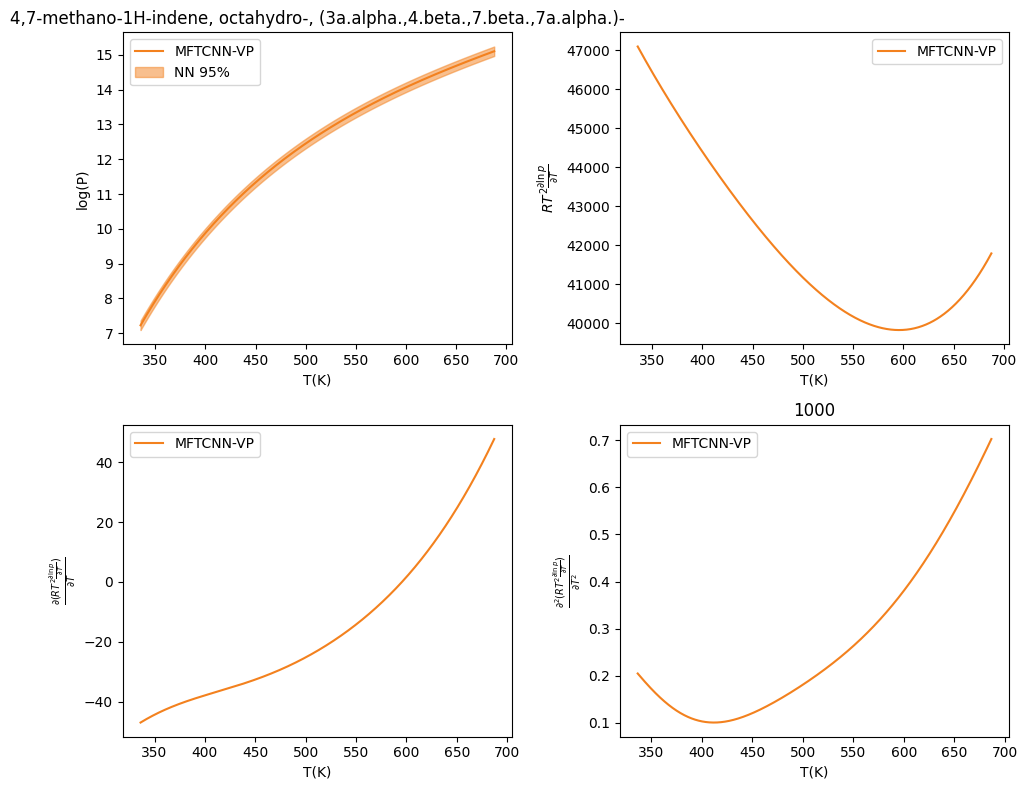

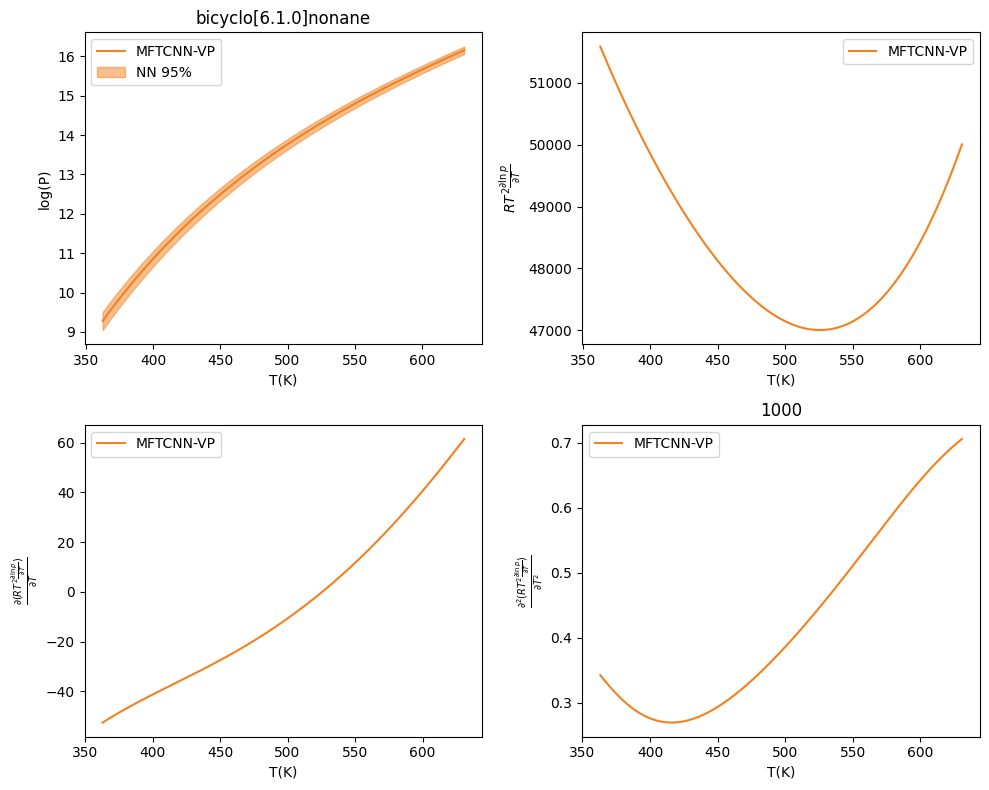

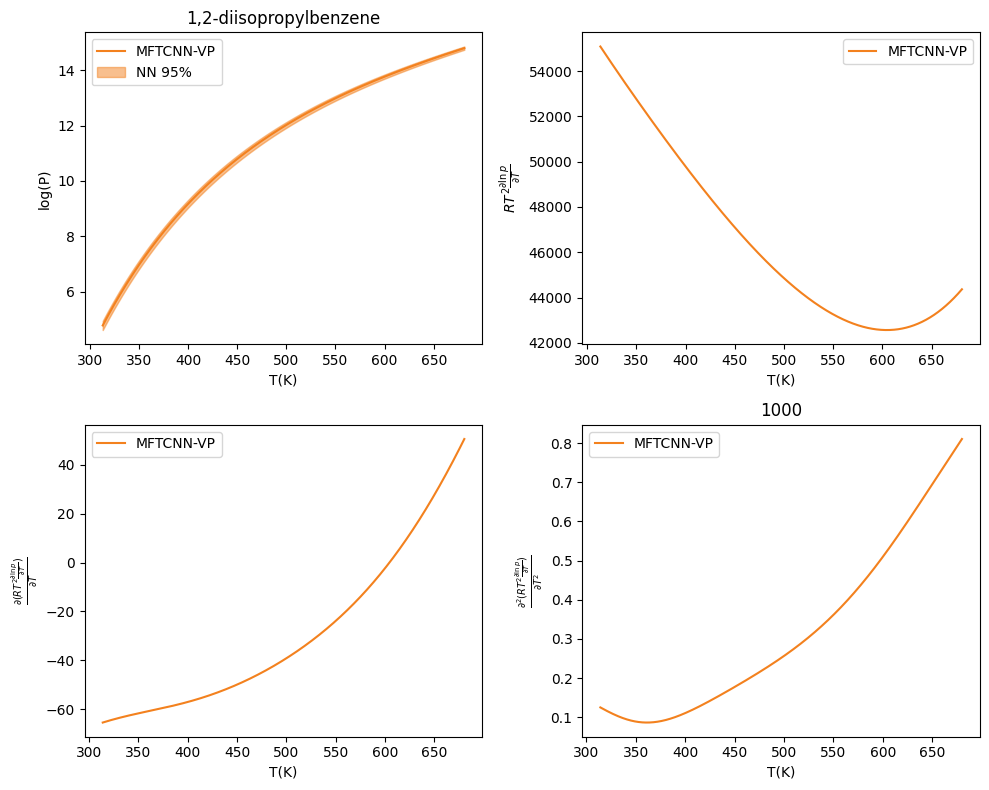

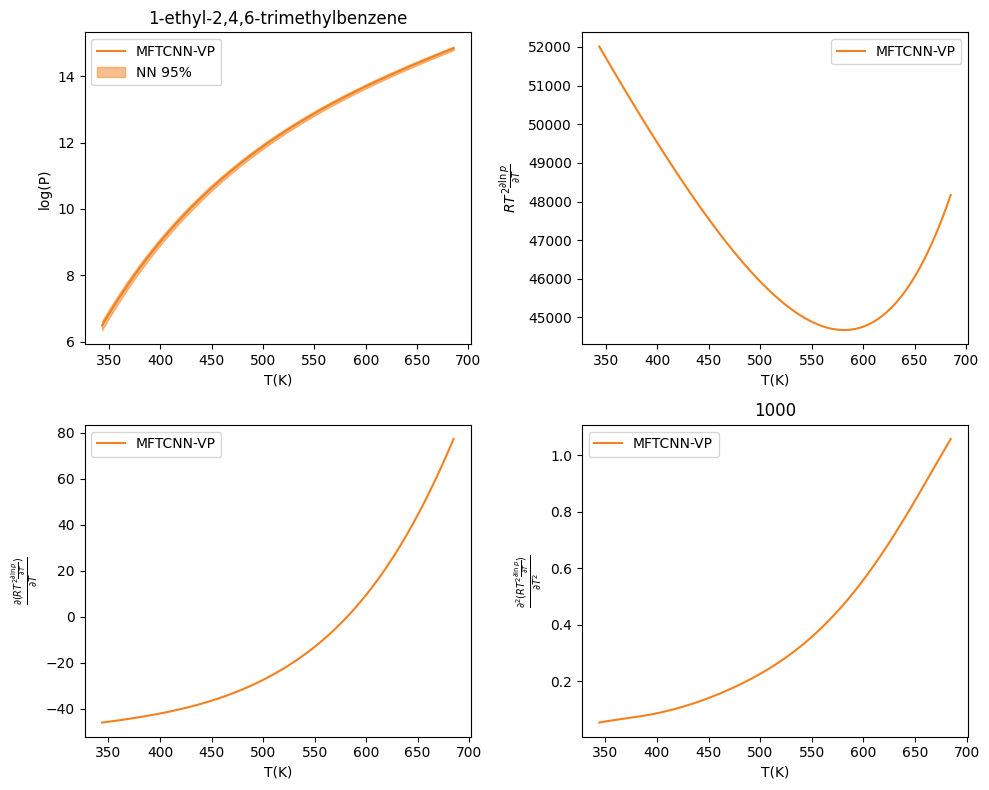

In [6]:
import matplotlib.pyplot as plt
from model import Net
import numpy as np
import pandas as pd
from scipy.constants import R
import torch
import torch.nn as nn
import torch.nn.functional as F

# 随机数种子
seed = 218105633
torch.manual_seed(seed)
np.random.seed(seed)
# 训练的物质数量
count_substance = 459
# 每个物质的数据量
count_data = 1000

# 测试的物质
substance = [
        "3,6-methano-1,4-cyclohexadiene", # P
    "1,3,5-cycloheptatriene",
    "1-butylcyclopentene",
    "1-methylcyclohexene",
    "2-methyltetradecane",
    "4-methylcyclohexene",
    "cyclopentacycloheptene",
    'cis-2,2-dimethyl-3-hexene',
    'trans-2,2-dimethyl-3-hexene',
    'cis-3-decene',
    'trans-3-decene',
    'cis-4,4-dimethyl-2-pentene',
    'trans-tert-butyl-2-methylethylene',
    'cis-3-nonene',
    'trans-3-nonene',
    'cis-4-decene',
    'cis-5-decene',
    'trans-4-decene',
    'trans-5-decene',
    'cis-perhydroindene',
    'trans-perhydroindene',
    '1,3-di-tert-butylbenzene',
    '1,1,4,7-tetramethylindan',
    '1-methyl-2-butylacetylene',
    'cyclobutane, methylene-',
    '.beta.-myrcene',
    '(.+-.)-3-carene',
    '1,3-bis(1,1-dimethylethyl)-5-methylbenzene',
    'spiro[2.2]pentane',
    '1,1\'-bicyclopentyl',
    '1-ethyl-2-phenylbenzene',
    'bicyclo[4.2.0]octane',
    '1H-indene, octahydro-, trans-',
    '1-cyclohexylhexane',
    '1,2-dihydronaphthalene',
    '8,9,10-trinorcarane',
    '4,7-methano-1H-indene, octahydro-, (3a.alpha.,4.beta.,7.beta.,7a.alpha.)-',
    'bicyclo[6.1.0]nonane',
    '1,2-diisopropylbenzene',
    '1-ethyl-2,4,6-trimethylbenzene',
]
# 加载模型
model_name = [
    1131796,
    8017474,
    18094361,
    26318864,
    28378614,
    157564161,
    218105633,
    609641183,
    1228297609,
    4227255766
]
model = []
for i in range(len(model_name)):
    model.append(Net())
    model[i].load_state_dict(torch.load(f'../model/model_{model_name[i]}.pt', weights_only=True))
    model[i].eval()
    # 模型转化为double类型
    model[i] = model[i].double()
    model[i] = torch.jit.script(model[i])
mean_std = pd.read_csv('../database/mean_std.csv')
mean = mean_std['mean'].values
std = mean_std['std'].values
filterdata = pd.read_csv('../database/HC459_testset.csv')
# 读取实验数据
expdata = pd.read_csv('../database/testset_exp.csv')
# 选出substance中的物种
subdata = filterdata[filterdata['Name'].isin(substance)]
subdata.reset_index(inplace=True, drop=True)

# 饱和蒸汽压计算（Extended Antoine）
def vap_pressure(t, params):
    a, b, c, d, e, f, g = params
    return np.exp(a + b / (t + c) + d * t + e * np.log(t) + f * (t ** g))

def Waring(t, params):
    a, b, c, d, e, f, g = params
    return R * t * (e + d * t + f * g * (t ** g) - b * t / ((c + t) ** 2))

B = np.log(100000)
t_0_025 = 2.306
n = len(model_name)
for i in range(len(substance)):
    database = np.zeros((1000, 45), dtype=np.double)
    feature = subdata.iloc[i, 2:46].values
    feature = (feature - mean) / std
    # 读取当前物质对应的实验物质点
    exp = expdata[expdata['name'] == subdata.iloc[i, 0]]
    exp_T = exp['temperature'].values
    Tlower = exp_T.min()
    if(np.isnan(subdata.loc[i, 'TC'])):
        Tupper = exp_T.max() + 10
    else:
        Tupper = subdata.loc[i, 'TC']
    # 读取临界温度和临界压力
    Tc = subdata.loc[i, 'TC']
    Pc = subdata.loc[i, 'PC']
    # 生成Tr数据
    T = np.linspace(Tlower,Tupper, 1000, dtype=np.double) 
    database[:, 0:44] = feature
    database[:, 44] = T / Tc
    # 预测
    y_pred = []
    with torch.no_grad():
        database = torch.from_numpy(database)
        for j in range(len(model_name)):
            y_pred.append(model[j](database[:, 0:44], database[:, 44:45]).numpy().flatten())
    y_pred = np.array(y_pred)
    # 计算平均值
    y_hat = np.mean(y_pred, axis=0)
    # 计算标准差
    y_std = np.std(y_pred, axis=0, ddof=1)
    # 计算平均值
    A = np.log(Pc) - B
    p_pred = y_hat * A + B
    y_conf = t_0_025 * A * y_std / np.sqrt(n)
    p_low = p_pred - y_conf
    p_high = p_pred + y_conf
    dP_dT = R * (T ** 2) * np.gradient(p_pred, T)
    p_pred = np.exp(p_pred)
    p_low = np.exp(p_low)
    p_high = np.exp(p_high)
    # 画图
    plt.figure(figsize=(10, 8))
    plt.subplot(2, 2, 1) # 创建子图
    plt.plot(T, np.log(p_pred), label='MFTCNN-VP', color = "#F3811E")
    # 绘制置信区间
    plt.fill_between(T, np.log(p_low), np.log(p_high), alpha=0.5, label='NN 95%', color = "#F3811E")
    plt.xlabel('T(K)')
    plt.ylabel('log(P)')
    plt.legend()
    plt.title(f'{subdata.iloc[i, 0]}')
    plt.subplot(2, 2, 2) # 创建子图
    dP_dT = dP_dT[1:-1]
    plt.plot(T[1:-1], dP_dT, label='MFTCNN-VP', color = "#F3811E")
    T = T[1:-1]
    plt.xlabel('T(K)')
    plt.ylabel(r'$R T^2 \frac{\partial \ln{p}}{\partial T}$')
    plt.legend()
    plt.subplot(2, 2, 3) # 创建子图
    d2P_dT2 = np.gradient(dP_dT, T)
    T = T[1:-1]
    d2P_dT2 = d2P_dT2[1:-1]
    plt.plot(T, d2P_dT2, label='MFTCNN-VP', color = "#F3811E")
    plt.xlabel('T(K)')
    plt.ylabel(r'$\frac{\partial (R T^2 \frac{\partial \ln{p}}{\partial T})}{\partial T}$')
    plt.legend()
    plt.subplot(2, 2, 4) # 创建子图
    d3P_dT3 = np.gradient(d2P_dT2, T)
    T = T[1:-1]
    d3P_dT3 = d3P_dT3[1:-1]
    plt.plot(T, d3P_dT3, label='MFTCNN-VP', color = "#F3811E")
    plt.xlabel('T(K)')
    plt.ylabel(r'$\frac{\partial^2 (R T^2 \frac{\partial \ln{p}}{\partial T})}{\partial T^2}$')
    plt.legend()
    plt.title(f'{count_data}')
    plt.tight_layout()
    plt.show()
